In [2]:
!pip install -q google-generativeai pandas matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-google-genai 2.1.4 requires google-ai-generativelanguage<0.7.0,>=0.6.18, but you have google-ai-generativelanguage 0.6.15 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import google.generativeai as genai
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\SRINIDHI\AppData\Local\Temp\ipykernel_7024\2674229674.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [4]:
from dotenv import load_dotenv
import os
import google.generativeai as genai

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

genai.configure(api_key=api_key)

In [5]:
model = genai.GenerativeModel("gemini-2.5-flash")

In [6]:
def generate_response(prompt):
    response = model.generate_content(prompt)
    return response.text

In [7]:
problem = """
A train travels 60 km in 1 hour.
How far will it travel in 3.5 hours?
"""

print(problem)


A train travels 60 km in 1 hour.
How far will it travel in 3.5 hours?



In [8]:
zero_shot_prompt = f"""
Solve the following problem.

{problem}
"""

zero_shot_output = generate_response(zero_shot_prompt)

print("Zero Shot Result:\n")
print(zero_shot_output)

Zero Shot Result:

To find out how far the train will travel in 3.5 hours, we can multiply its speed (distance per hour) by the total time.

Given:
Speed = 60 km per hour
Time = 3.5 hours

Distance = Speed × Time
Distance = 60 km/hour × 3.5 hours
Distance = 210 km

The train will travel 210 km in 3.5 hours.


In [9]:
few_shot_prompt = f"""
Example 1:
A car travels 50 km in 1 hour. How far in 4 hours?
Answer: 200 km

Example 2:
A bike travels 30 km in 1 hour. How far in 2 hours?
Answer: 60 km

Now solve:

{problem}
"""

few_shot_output = generate_response(few_shot_prompt)

print("Few Shot Result:\n")
print(few_shot_output)

Few Shot Result:

A train travels 60 km in 1 hour.
To find out how far it travels in 3.5 hours, multiply the distance per hour by the number of hours:

60 km/hour * 3.5 hours = 210 km

Answer: 210 km


In [10]:
cot_prompt = f"""
Solve the problem step by step.

Explain your reasoning clearly before giving the final answer.

Problem:
{problem}
"""

cot_output = generate_response(cot_prompt)

print("Chain of Thought Result:\n")
print(cot_output)

Chain of Thought Result:

To solve this problem, we need to determine the train's speed and then use that speed to calculate the distance it travels in a longer period.

Here's the step-by-step solution:

**Step 1: Determine the train's speed.**
The problem states that the train travels 60 km in 1 hour.
Speed is calculated as Distance / Time.
Speed = 60 km / 1 hour
Speed = 60 km/h

**Step 2: Calculate the distance traveled in 3.5 hours.**
Now that we know the train's speed is 60 km/h, we can find out how far it will travel in 3.5 hours using the formula: Distance = Speed × Time.
Distance = 60 km/h × 3.5 hours

**Step 3: Perform the multiplication.**
Distance = 60 × 3.5
Distance = 210 km

**Reasoning:**
The problem provides a direct relationship between distance and time for the train, which allows us to determine its constant speed. Once the speed is known, we can apply the fundamental formula (Distance = Speed × Time) to calculate the distance for any given duration, assuming the spee

In [11]:
interview_prompt = f"""
Let's solve this problem like an interview.

Question 1: What is the speed of the train?
Question 2: What is the time given?
Question 3: Which formula relates distance, speed and time?
Question 4: Calculate the final distance.

Problem:
{problem}

Answer step by step.
"""

interview_output = generate_response(interview_prompt)

print("Interview Prompting Result:\n")
print(interview_output)

Interview Prompting Result:

Okay, let's break this down step-by-step, just like in an interview.

---

**Problem:**
A train travels 60 km in 1 hour. How far will it travel in 3.5 hours?

---

**Question 1: What is the speed of the train?**

*   **Thought Process:** To find the speed, we use the initial information provided: a distance traveled over a specific time.
*   **Formula:** Speed (S) = Distance (D) / Time (T)
*   **Calculation:**
    *   Distance = 60 km
    *   Time = 1 hour
    *   Speed = 60 km / 1 hour = 60 km/h

*   **Answer:** The speed of the train is **60 km/h**.

---

**Question 2: What is the time given?**

*   **Thought Process:** This question refers to the time for which we need to calculate the *new* distance, as asked in the problem's final question.
*   **Identification:** The problem asks "How far will it travel in **3.5 hours**?"

*   **Answer:** The time given for the final calculation is **3.5 hours**.

---

**Question 3: Which formula relates distance, spe

In [12]:
tot_prompt = f"""
Solve the following problem using Tree of Thought reasoning.

Step 1: Generate multiple possible approaches.
Step 2: Evaluate each approach.
Step 3: Choose the best solution.

Problem:
{problem}

Explain your reasoning tree and give the final answer.
"""

tot_output = generate_response(tot_prompt)

print("Tree of Thought Result:\n")
print(tot_output)

Tree of Thought Result:

**Problem:** A train travels 60 km in 1 hour. How far will it travel in 3.5 hours?

---

**Reasoning Tree:**

**Step 1: Generate multiple possible approaches.**

*   **Approach 1: Direct Proportionality / Unit Rate Method**
    *   Recognize that the speed of the train is given directly (60 km per hour).
    *   Use the formula: Distance = Speed × Time.
    *   Substitute the known speed and the new time to find the total distance.

*   **Approach 2: Ratio and Proportion**
    *   Set up a ratio: (Distance1 / Time1) = (Distance2 / Time2).
    *   Substitute the given values (60 km for 1 hour) and the new time (3.5 hours) to solve for the unknown distance.

*   **Approach 3: Step-by-step calculation (for integer and fractional parts)**
    *   Calculate the distance for the integer part of the time (3 hours).
    *   Calculate the distance for the fractional part of the time (0.5 hours).
    *   Add the distances from both parts to get the total.

**Step 2: Eval

In [13]:
results = {
    "Technique": [
        "Zero Shot",
        "Few Shot",
        "Chain of Thought",
        "Interview Prompting",
        "Tree of Thought"
    ],
    "Output": [
        zero_shot_output,
        few_shot_output,
        cot_output,
        interview_output,
        tot_output
    ]
}

df = pd.DataFrame(results)
df

,Technique,Output
0,Zero Shot,To find out how far the train will travel in 3...
1,Few Shot,A train travels 60 km in 1 hour.\nTo find out ...
2,Chain of Thought,"To solve this problem, we need to determine th..."
3,Interview Prompting,"Okay, let's break this down step-by-step, just..."
4,Tree of Thought,**Problem:** A train travels 60 km in 1 hour. ...


In [14]:
comparison = pd.DataFrame({
    "Technique": [
        "Zero Shot",
        "Few Shot",
        "Chain of Thought",
        "Interview Prompting",
        "Tree of Thought"
    ],
    "Reasoning Level": [
        "Low",
        "Medium",
        "High",
        "High",
        "Very High"
    ],
    "Accuracy": [
        "Medium",
        "High",
        "High",
        "High",
        "Very High"
    ],
    "Best Applications": [
        "Simple queries",
        "Pattern learning",
        "Math, logic problems",
        "Educational tutoring",
        "Complex planning & decision making"
    ]
})

comparison

,Technique,Reasoning Level,Accuracy,Best Applications
0,Zero Shot,Low,Medium,Simple queries
1,Few Shot,Medium,High,Pattern learning
2,Chain of Thought,High,High,"Math, logic problems"
3,Interview Prompting,High,High,Educational tutoring
4,Tree of Thought,Very High,Very High,Complex planning & decision making


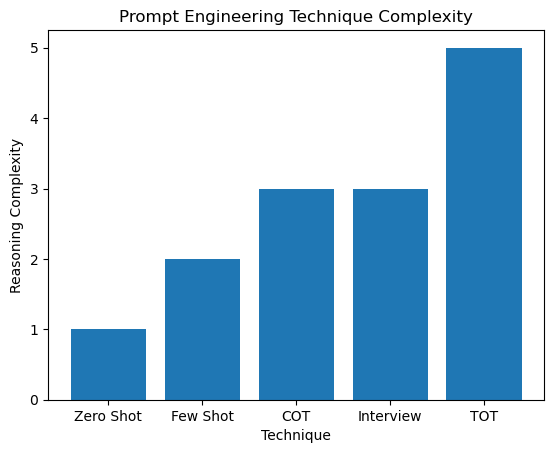

In [15]:
techniques = ["Zero Shot","Few Shot","COT","Interview","TOT"]
complexity = [1,2,3,3,5]

plt.bar(techniques, complexity)
plt.title("Prompt Engineering Technique Complexity")
plt.xlabel("Technique")
plt.ylabel("Reasoning Complexity")
plt.show()